In [1]:
# Автор: Проценко Іван Андрійович 4-10
#
# Не був присутній на парі, буду виконувати 2 завдання
#
# Лінійна регресія


import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1 спосіб зчитати файл (попередньо завантажений на комп'ютер)
df = pd.read_csv('house_price_regression_dataset.csv')
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [4]:
# Перевіримо на дублікати
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [7]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [9]:
# ще так можна перевірити пропущені значення
#
# вивести значення для стовпчика Neighborhood_Quality

df['Neighborhood_Quality'].value_counts()

Neighborhood_Quality
10    123
5     109
2     105
7     102
6     101
4      99
8      97
1      91
9      88
3      85
Name: count, dtype: int64

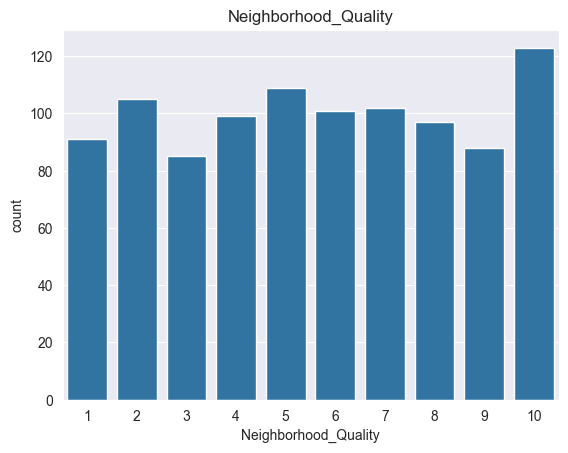

In [10]:
# Побудувати діаграму для Neighborhood_Quality
sns.countplot(x='Neighborhood_Quality', data=df)
plt.title('Neighborhood_Quality')
plt.show()

In [11]:
# Перевіримо значення в стовпці Num_Bathrooms
df['Num_Bathrooms'].value_counts()

Num_Bathrooms
1    350
2    327
3    323
Name: count, dtype: int64

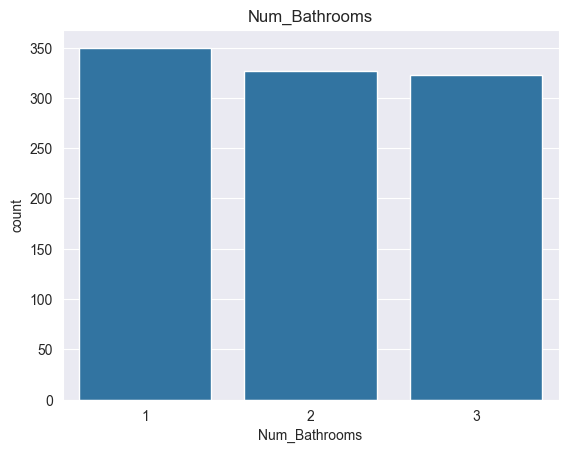

In [12]:
# побудуємо гістограму

sns.countplot(x='Num_Bathrooms', data=df)
plt.title('Num_Bathrooms')
plt.show()

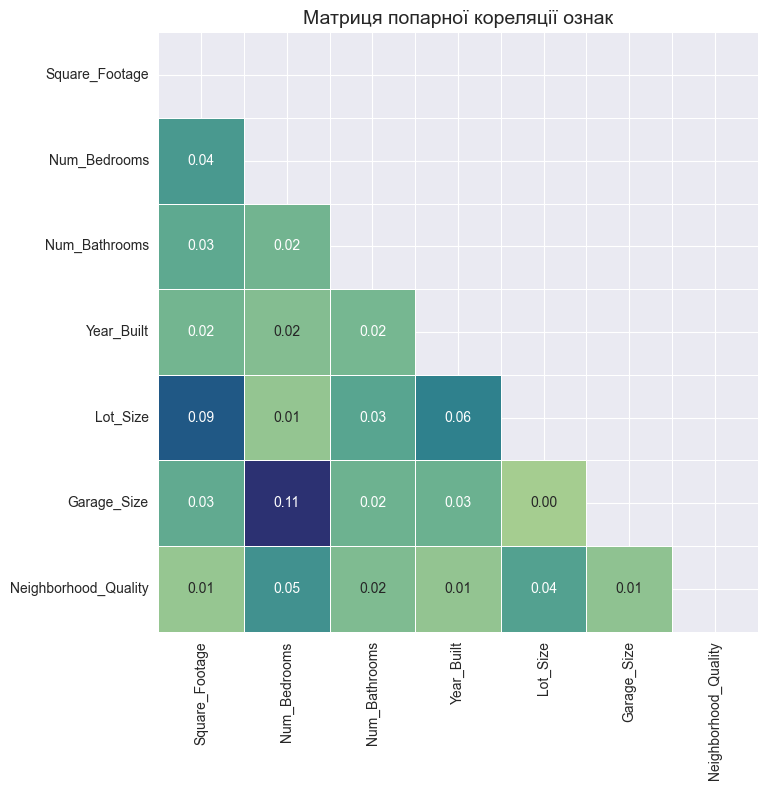

In [13]:

mtx = df.drop('House_Price', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(
    mtx,
    cmap='crest',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()


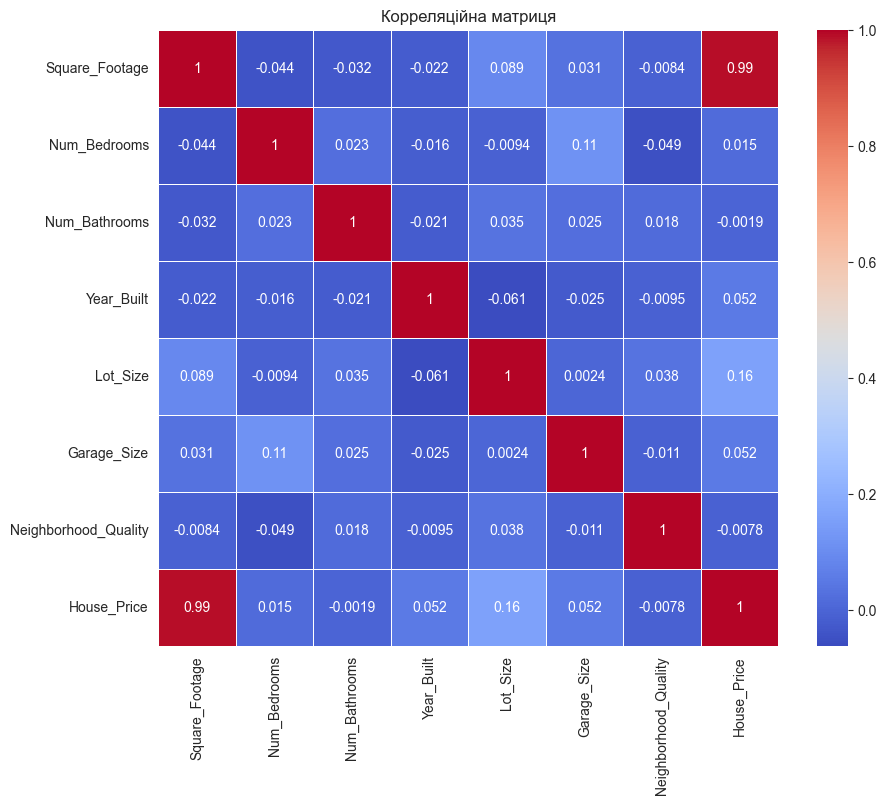

In [15]:
# можна ще в такому вигляді
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляційна матриця')
plt.show()

In [17]:
# вивести кореляцію між ознаками і цільовою змінною
correlation_with_House_Price = correlation_matrix['House_Price'].sort_values(ascending=False)
correlation_with_House_Price

House_Price             1.000000
Square_Footage          0.991261
Lot_Size                0.160412
Garage_Size             0.052133
Year_Built              0.051967
Num_Bedrooms            0.014633
Num_Bathrooms          -0.001862
Neighborhood_Quality   -0.007770
Name: House_Price, dtype: float64

In [19]:
# Побудуємо моделі

# імпортуємо бібліотеки

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [20]:
# відокремимо цільову змінну поділимо датасет на тренувальну і тестову вибірку

X = df.drop(columns=['House_Price'])
y = df['House_Price']

In [22]:
# маштабуємо ознаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [23]:
# побудуємо моделі
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = model.score(X_train, y_train)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "R²": r2,
        "MAE": mae,
        "MSE": mse
    }

    print(f"[{name}] R²: {r2:.6f} | MAE: {mae:.3f} | MSE: {mse:.3f}")

[LinearRegression] R²: 0.998538 | MAE: 8174.584 | MSE: 101434798.506
[Ridge] R²: 0.998536 | MAE: 8241.898 | MSE: 102486578.622
[Lasso] R²: 0.998538 | MAE: 8174.607 | MSE: 101435079.238
[Random Forest] R²: 0.998984 | MAE: 15892.685 | MSE: 386435250.458
[Gradient Boosting] R²: 0.998783 | MAE: 12346.476 | MSE: 226395951.324


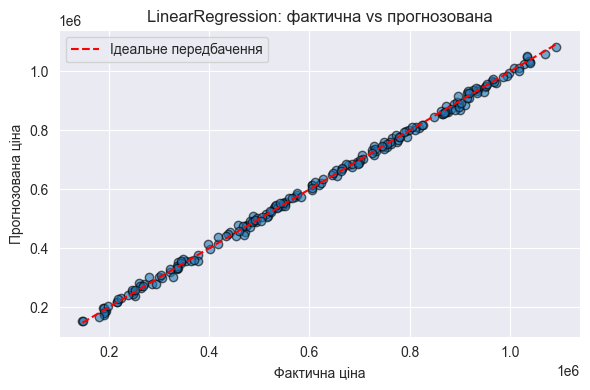

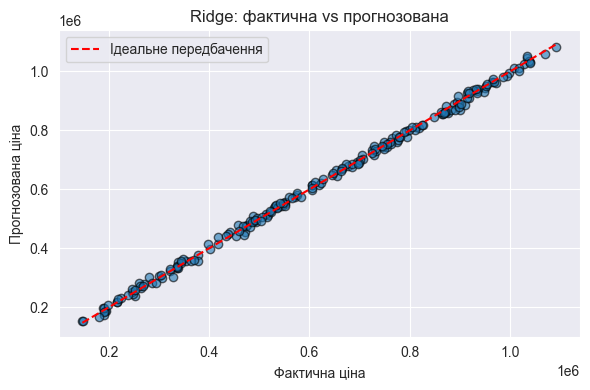

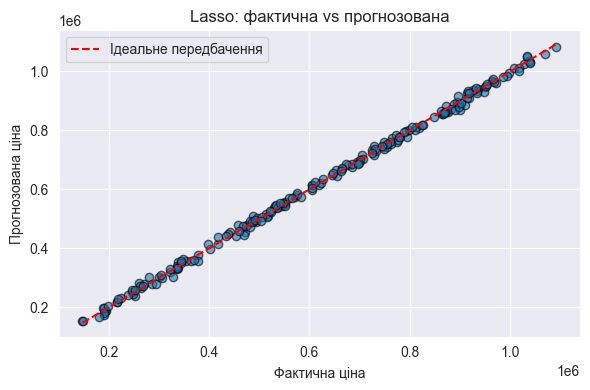

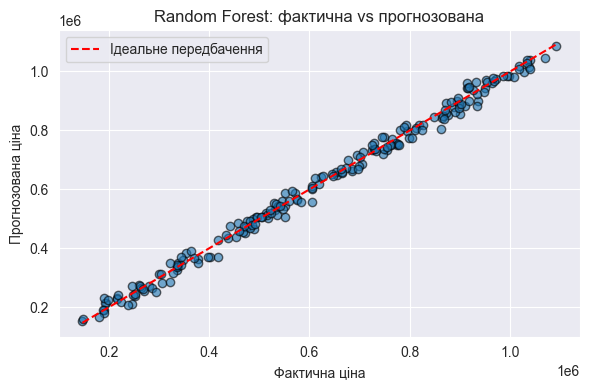

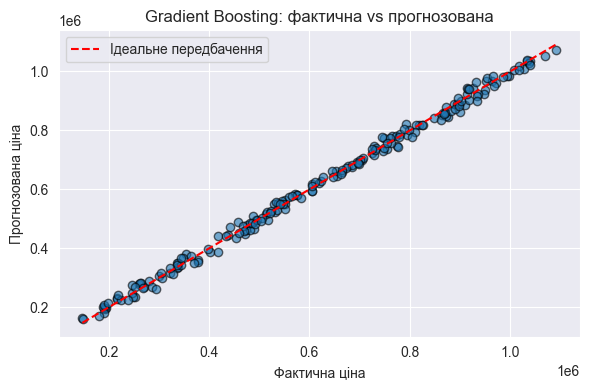

In [24]:
# Вивести графік розподілу справжніх і прогнозованих
for name, res in results.items():
    plt.figure(figsize=(6, 4))
    plt.scatter(y_test, res["y_pred"], alpha=0.6, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', label='Ідеальне передбачення')

    plt.xlabel("Фактична ціна")
    plt.ylabel("Прогнозована ціна")
    plt.title(f"{name}: фактична vs прогнозована")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [26]:
# Підібрати оптимальні параметри для моделі random forest
from sklearn.model_selection import GridSearchCV
param_rf = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
}


In [36]:
rf_reg_gs = RandomForestRegressor(random_state=42)
rf_search = GridSearchCV(estimator=rf_reg_gs, param_grid = param_rf, cv=3)
rf_search.fit(X_train, y_train)
best_rf_params = rf_search.best_params_

KeyboardInterrupt: 

In [ ]:
best_rf_params

In [32]:
rf_optimal = RandomForestRegressor(**best_rf_params, random_state=42)
rf_optimal.fit(X_train, y_train)
y_pred_rf_optimal = rf_optimal.predict(X_test)

In [33]:
# Розрахунки для тестових даних
rf_mse = mean_squared_error(y_test, y_pred_rf_optimal )
rf_mae = mean_absolute_error(y_test, y_pred_rf_optimal )
rf_r2 = r2_score(y_test, y_pred_rf_optimal )

In [34]:
# Вивести метрики моделі з оптимальними параметрами
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("R2:", rf_r2)


MSE: 400038896.87978363
MAE: 16137.413976430662
R2: 0.99379388783849


In [35]:
# До підбору параметрів [Random Forest] R²: 0.998960 | MAE: 15833.409 | MSE: 376172438.005
#
# Зробити висновок, як краще, з оптимальними параметрами чи ні.
#
# Отримуємо передбачення для лінійної регресії
linreg_pred = results['LinearRegression']['y_pred']

# Створюємо DataFrame для аналізу
comparison_df = pd.DataFrame({
    "Фактична ціна": y_test.values,
    "Передбачена ціна": linreg_pred,
})
comparison_df["Похибка, %"] = (np.abs(comparison_df["Передбачена ціна"] - comparison_df["Фактична ціна"])/comparison_df["Фактична ціна"])*100

# Вибираємо 10 випадкових рядків
sample = comparison_df.sample(10, random_state=42)

# Виводимо
print(sample.round(2))


     Фактична ціна  Передбачена ціна  Похибка, %
95      1068538.11        1059729.02        0.82
15       194353.74         187868.55        3.34
30       270230.64         279715.82        3.51
158      986006.86         981949.27        0.41
128      953339.73         957382.95        0.42
115      914555.75         909764.27        0.52
69       746167.73         742469.14        0.50
170      646766.29         654445.55        1.19
174      523323.07         524605.44        0.25
45      1008539.16        1011343.64        0.28


In [ ]:
# Висновок: У ході виконання завдання було завантажено датасет Diabetes, проведено попередній аналіз, перевірено пропуски й дублікати, виконано кодування та масштабування даних. Після аналізу кореляцій визначено найважливіші фактори, що впливають на прогрес діабету. Побудовано моделі лінійної регресії та RandomForestRegressor, проведено відбір ознак і порівняння метрик. Результати показали, що RandomForest забезпечує вищу точність і меншу помилку, тому ансамблеві методи є ефективнішими для прогнозування, тоді як лінійна регресія підходить для базового аналізу.

In [37]:
# Завдання 2
# Автор: Проценко Іван Андрійович
# На парі не був присутній

In [39]:
# Завантажити датасет California Housing Dataset, що містить інформацію про житло в Каліфорнії. Вивести перших 5 рядків.
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Завантаження датасету
data = fetch_california_housing()

# Перетворення у DataFrame
df_california = pd.DataFrame(data.data, columns=data.feature_names)
df_california['MedHouseValue'] = data.target

print(df_california.head())

df_california.to_csv("california_housing.csv", index=False)


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseValue  
0    -122.23          4.526  
1    -122.22          3.585  
2    -122.24          3.521  
3    -122.25          3.413  
4    -122.25          3.422  


In [41]:
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [44]:
# Перевірити наявність пропусків. У разі виявлення замінити на середнє значення.
if df_california.isnull().sum().sum() > 0:
    df_california = df.fillna(df.mean())
df_california

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [46]:
# Перевірити наявність дублікатів, при виявленні – видалити.
df_california.drop_duplicates()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [47]:
# Перевірити тип даних. При необхідності замінити тип даних на числовий.
df_california = df_california.apply(pd.to_numeric, errors='coerce')
df_california

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [48]:
# 2. Масштабувати ознаки.3. Поділити дані на тренувальні і тестові.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [51]:
X = df_california.drop(columns=['HouseAge'])
y = df_california['HouseAge']
print(X)
print(y)

       MedInc  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  \
0      8.3252  6.984127   1.023810       322.0  2.555556     37.88    -122.23   
1      8.3014  6.238137   0.971880      2401.0  2.109842     37.86    -122.22   
2      7.2574  8.288136   1.073446       496.0  2.802260     37.85    -122.24   
3      5.6431  5.817352   1.073059       558.0  2.547945     37.85    -122.25   
4      3.8462  6.281853   1.081081       565.0  2.181467     37.85    -122.25   
...       ...       ...        ...         ...       ...       ...        ...   
20635  1.5603  5.045455   1.133333       845.0  2.560606     39.48    -121.09   
20636  2.5568  6.114035   1.315789       356.0  3.122807     39.49    -121.21   
20637  1.7000  5.205543   1.120092      1007.0  2.325635     39.43    -121.22   
20638  1.8672  5.329513   1.171920       741.0  2.123209     39.43    -121.32   
20639  2.3886  5.254717   1.162264      1387.0  2.616981     39.37    -121.24   

       MedHouseValue  
0   

In [53]:
# маштабуємо ознаки

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Fitting 3 folds for each of 3 candidates, totalling 9 fits

🔹 Linear Regression
R² = 0.2132
MSE = 123.2610

🔹 Ridge Regression
R² = 0.2132
MSE = 123.2610

🔹 Random Forest
R² = 0.5445
MSE = 71.3580


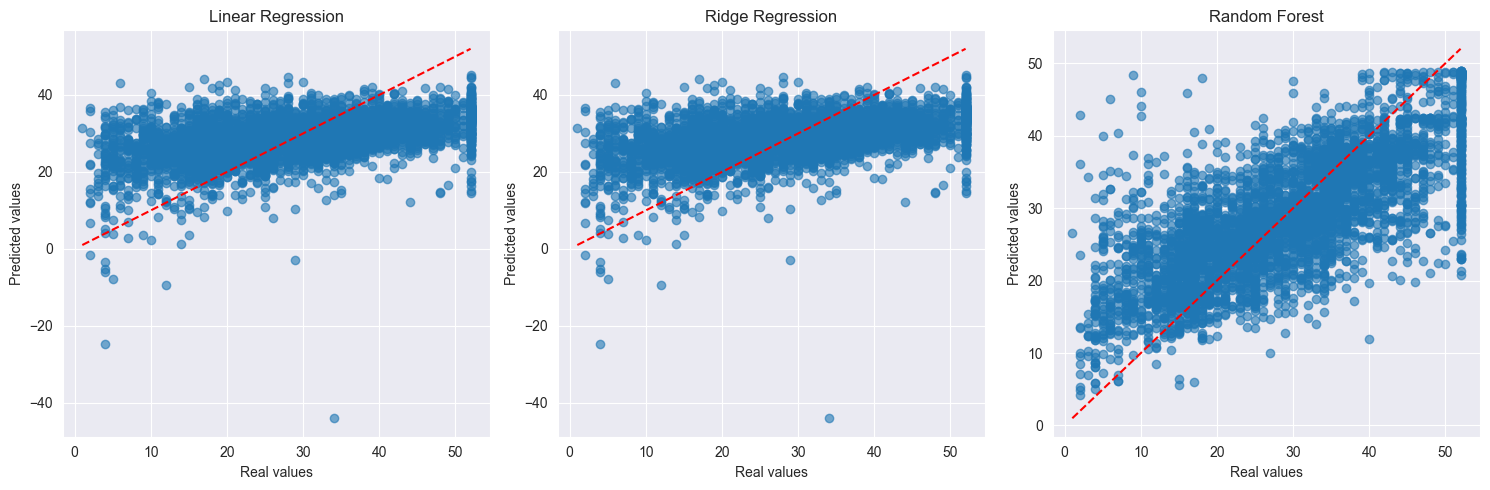

In [64]:
# Побудувати 3 моделі: лін. Регресія, регресія випадковий ліс, Ridge. Підібрати оптимальні параметри за допомогою GridSeach. Вивести R2 і MSE Побудувати графіки.
lr = LinearRegression()
lr.fit(X_train, y_train)
q_pred_lr = lr.predict(X_test)

# Ridge з GridSearchCV
ridge = Ridge()
params_ridge = {'alpha': [0.1, 1, 10]}
grid_ridge = GridSearchCV(ridge, params_ridge, cv=3, n_jobs=-1, verbose=1)
grid_ridge.fit(X_train, y_train)
q_pred_ridge = grid_ridge.predict(X_test)

# Random Forest з GridSearchCV
rf = RandomForestRegressor(random_state=42)
params_rf = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
grid_rf = GridSearchCV(rf, params_rf, cv=2, n_jobs=-1)
grid_rf.fit(X_train, y_train)
q_pred_rf = grid_rf.predict(X_test)

# Результати
models = {
    "Linear Regression": q_pred_lr,
    "Ridge Regression": q_pred_ridge,
    "Random Forest": q_pred_rf,
}

for name, y_pred in models.items():
    print(f"\n🔹 {name}")
    print(f"R² = {r2_score(y_test, y_pred):.4f}")
    print(f"MSE = {mean_squared_error(y_test, y_pred):.4f}")

# Побудова графіків
plt.figure(figsize=(15, 5))
for i, (name, y_pred) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Real values")
    plt.ylabel("Predicted values")
    plt.title(name)
plt.tight_layout()
plt.show()

In [65]:
# Вивести справжні і прогнозовані значення
results_rf = pd.DataFrame({
    "Real Values": y_test,
    "Predicted Values": q_pred_rf
})

print(results_rf.head(10))

results_all = pd.DataFrame({
    "Real": y_test,
    "Linear Regression": q_pred_lr,
    "Ridge Regression": q_pred_ridge,
    "Random Forest": q_pred_rf
})

print(results_all.head(10))

       Real Values  Predicted Values
20046         25.0         28.963278
3024          30.0         26.585961
15663         52.0         46.508733
20484         17.0         23.896531
9814          34.0         31.381512
13311         12.0         19.429982
7113          36.0         33.729423
7668          38.0         34.569050
18246          4.0         22.119936
5723          45.0         41.869758
       Real  Linear Regression  Ridge Regression  Random Forest
20046  25.0          26.612349         26.612548      28.963278
3024   30.0          28.179517         28.179242      26.585961
15663  52.0          39.968632         39.968728      46.508733
20484  17.0          25.328590         25.328453      23.896531
9814   34.0          36.979155         36.978619      31.381512
13311  12.0          20.700168         20.700363      19.429982
7113   36.0          28.240384         28.240307      33.729423
7668   38.0          29.470107         29.470015      34.569050
18246   4.0      

In [ ]:
# Висновки:
# У результаті моделювання було побудовано три моделі: лінійну регресію, Ridge та Random Forest.
# Найкращі результати показала модель Random Forest, яка досягла найвищого коефіцієнта детермінації (R²) та найменшої середньоквадратичної помилки (MSE).
# Це свідчить про те, що ансамблеві методи краще враховують нелінійні залежності між ознаками житла.
# Лінійна та Ridge-регресії показали схожі результати, придатні для базового аналізу даних.